# Regressão por Cluster

## Objetivo

Treinar modelos de regressão específicos para cada cluster identificado na etapa de clusterização.

A hipótese é que clientes pertencentes ao mesmo grupo apresentam comportamentos mais semelhantes, permitindo que modelos especializados realizem previsões mais precisas do que um único modelo global.

Serão avaliados:

- Regressão Linear
- KNN Regressor
- Decision Tree Regressor

As métricas utilizadas serão:

- MAE
- MSE
- RMSE
- R²

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Carregamento dos Dados

Nesta etapa utilizamos:

- Dados preparados
- Rótulos dos clusters gerados pelo K-Means

Cada registro será associado ao cluster ao qual pertence.

In [2]:
X = pd.read_csv('../data/X_scaled.csv')
y = pd.read_csv('../data/y.csv').squeeze()
clusters = pd.read_csv('../data/cluster_labels.csv').squeeze()
resultados_global = pd.read_csv('../data/resultados_global.csv')

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clusters shape: {clusters.shape}')
print(f'\nDistribuição de clusters:')
print(clusters.value_counts().sort_index())
print(f'\nBaseline global (Etapa 3):')
print(resultados_global.to_string(index=False))

X shape: (1338, 8)
y shape: (1338,)
Clusters shape: (1338,)

Distribuição de clusters:
cluster
0    649
1    325
2    364
Name: count, dtype: int64

Baseline global (Etapa 3):
                 Modelo         MAE          MSE        RMSE       R²
          KNN Regressor 3514.202219 3.061814e+07 5533.366286 0.802780
       Regressão Linear 4181.194474 3.359692e+07 5796.284659 0.783593
Decision Tree Regressor 3074.866286 4.015399e+07 6336.717525 0.741357


## Análise Exploratória por Cluster

Antes do treinamento dos modelos, analisamos a distribuição da variável alvo (`charges`) em cada cluster.

Essa etapa permite verificar se os grupos apresentam comportamentos distintos, justificando o uso de modelos de regressão especializados para cada segmento.

In [3]:
cluster_nomes = {
    0: 'Cluster 0\n(não-fumantes, custo baixo/médio)',
    1: 'Cluster 1\n(fumantes, custo alto)',
    2: 'Cluster 2\n(não-fumantes, mais velhos/filhos)'
}

stats = []
for cid in [0, 1, 2]:
    mask = clusters == cid
    charges_cluster = y[mask]
    stats.append({
        'Cluster': cid,
        'Amostras': mask.sum(),
        'Charges Médio': f"${charges_cluster.mean():,.2f}",
        'Charges Mín': f"${charges_cluster.min():,.2f}",
        'Charges Máx': f"${charges_cluster.max():,.2f}",
        'Desvio Padrão': f"${charges_cluster.std():,.2f}"
    })

print('Estatísticas de charges por cluster:')
print(pd.DataFrame(stats).to_string(index=False))

Estatísticas de charges por cluster:
 Cluster  Amostras Charges Médio Charges Mín Charges Máx Desvio Padrão
       0       649    $12,911.22   $1,621.34  $60,021.40    $11,166.62
       1       325    $12,346.94   $1,241.57  $52,590.83    $11,557.18
       2       364    $14,735.41   $1,121.87  $63,770.43    $13,971.10


### Interpretação

Diferenças significativas entre médias, desvios padrão e faixas de valores indicam que os clusters possuem comportamentos distintos em relação aos custos do seguro.

Quanto mais homogêneo for um cluster, maior tende a ser o potencial de melhoria dos modelos de regressão.

## Treinamento por Cluster

Para cada cluster:
- Filtramos `X` e `y` pelo rótulo do cluster
- Dividimos em treino (80%) e teste (20%) com `random_state=42`
- Treinamos os **mesmos 3 modelos da Etapa 3** para comparação direta
- Calculamos MAE, MSE, RMSE e R²

In [4]:
def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {'Modelo': nome, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2, 'y_pred': y_pred, 'objeto': modelo}


resultados_lista = []
modelos_por_cluster = {}
predicoes_por_cluster = {}

for cluster_id in [0, 1, 2]:
    print(f'\n--- Cluster {cluster_id} ---')
    mask = clusters == cluster_id
    X_c = X[mask].reset_index(drop=True)
    y_c = y[mask].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

    definicoes_modelos = [
        ('Regressão Linear', LinearRegression()),
        ('KNN Regressor', KNeighborsRegressor(n_neighbors=5)),
        ('Decision Tree Regressor', DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]

    melhor_r2 = -np.inf
    melhor_modelo = None
    melhor_predicoes = None

    for nome, modelo in definicoes_modelos:
        res = avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test)
        resultados_lista.append({
            'Cluster': cluster_id,
            'Modelo': res['Modelo'],
            'MAE': res['MAE'],
            'MSE': res['MSE'],
            'RMSE': res['RMSE'],
            'R²': res['R²'],
        })
        print(f"  {nome}: R²={res['R²']:.4f}  MAE=${res['MAE']:,.2f}")

        if res['R²'] > melhor_r2:
            melhor_r2 = res['R²']
            melhor_modelo = res['objeto']
            melhor_predicoes = (y_test.values, res['y_pred'])

    modelos_por_cluster[cluster_id] = melhor_modelo
    predicoes_por_cluster[cluster_id] = melhor_predicoes
    print(f'  >> Melhor modelo: {melhor_modelo.__class__.__name__} (R²={melhor_r2:.4f})')

resultados_df = pd.DataFrame(resultados_lista)


--- Cluster 0 ---
Treino: 519 | Teste: 130
  Regressão Linear: R²=0.6373  MAE=$4,278.50
  KNN Regressor: R²=0.6881  MAE=$3,540.22
  Decision Tree Regressor: R²=0.3581  MAE=$4,277.42
  >> Melhor modelo: KNeighborsRegressor (R²=0.6881)

--- Cluster 1 ---
Treino: 260 | Teste: 65
  Regressão Linear: R²=0.7581  MAE=$4,070.04
  KNN Regressor: R²=0.8176  MAE=$3,464.89
  Decision Tree Regressor: R²=0.7516  MAE=$3,104.99
  >> Melhor modelo: KNeighborsRegressor (R²=0.8176)

--- Cluster 2 ---
Treino: 291 | Teste: 73
  Regressão Linear: R²=0.8612  MAE=$3,286.58
  KNN Regressor: R²=0.9264  MAE=$2,627.72
  Decision Tree Regressor: R²=0.7611  MAE=$3,080.99
  >> Melhor modelo: KNeighborsRegressor (R²=0.9264)


## Interpretação dos Resultados

Os modelos serão comparados utilizando principalmente:

- R² (quanto maior, melhor)
- MAE (quanto menor, melhor)

A comparação com o baseline global permitirá avaliar se a clusterização contribuiu para melhorar a capacidade preditiva.

In [5]:
print('Métricas por Cluster e Modelo:')
print('=' * 80)
display_df = resultados_df.copy()
display_df['MAE'] = display_df['MAE'].map('${:,.2f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('${:,.2f}'.format)
display_df['R²'] = display_df['R²'].map('{:.4f}'.format)
display_df = display_df.drop(columns=['MSE'])
print(display_df.to_string(index=False))

print('\nMelhor modelo por cluster (maior R²):')
print('=' * 80)
melhor_por_cluster = resultados_df.loc[resultados_df.groupby('Cluster')['R²'].idxmax()]
for _, row in melhor_por_cluster.iterrows():
    print(f"  Cluster {int(row['Cluster'])}: {row['Modelo']}  R²={row['R²']:.4f}  MAE=${row['MAE']:,.2f}")

print('\nBaseline global (melhor — KNN):')
global_best = resultados_global.loc[resultados_global['R²'].idxmax()]
print(f"  {global_best['Modelo']}  R²={global_best['R²']:.4f}  MAE=${global_best['MAE']:,.2f}")

Métricas por Cluster e Modelo:
 Cluster                  Modelo       MAE      RMSE     R²
       0        Regressão Linear $4,278.50 $6,063.40 0.6373
       0           KNN Regressor $3,540.22 $5,622.67 0.6881
       0 Decision Tree Regressor $4,277.42 $8,066.17 0.3581
       1        Regressão Linear $4,070.04 $6,420.88 0.7581
       1           KNN Regressor $3,464.89 $5,575.57 0.8176
       1 Decision Tree Regressor $3,104.99 $6,507.09 0.7516
       2        Regressão Linear $3,286.58 $4,589.26 0.8612
       2           KNN Regressor $2,627.72 $3,342.84 0.9264
       2 Decision Tree Regressor $3,080.99 $6,021.57 0.7611

Melhor modelo por cluster (maior R²):
  Cluster 0: KNN Regressor  R²=0.6881  MAE=$3,540.22
  Cluster 1: KNN Regressor  R²=0.8176  MAE=$3,464.89
  Cluster 2: KNN Regressor  R²=0.9264  MAE=$2,627.72

Baseline global (melhor — KNN):
  KNN Regressor  R²=0.8028  MAE=$3,514.20


### Interpretação

Diferenças significativas entre médias, desvios padrão e faixas de valores indicam que os clusters possuem comportamentos distintos em relação aos custos do seguro.

Quanto mais homogêneo for um cluster, maior tende a ser o potencial de melhoria dos modelos de regressão.

## Visualizações dos Resultados

Os gráficos facilitam a comparação entre os modelos treinados em cada cluster e o modelo global utilizado como baseline.

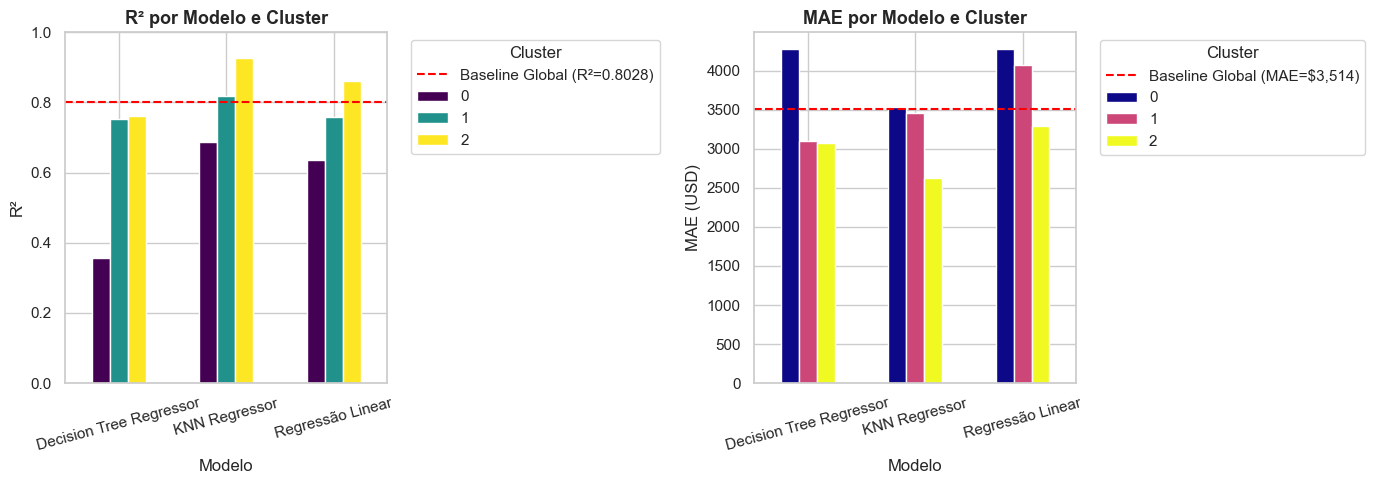

Gráfico salvo: data/comparacao_modelos_clusters.png


In [6]:
# --- Gráfico 1: R² por modelo × cluster ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r2_pivot = resultados_df.pivot(index='Modelo', columns='Cluster', values='R²')
r2_pivot.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='white')
global_best_r2 = resultados_global['R²'].max()
axes[0].axhline(y=global_best_r2, color='red', linestyle='--', linewidth=1.5, label=f'Baseline Global (R²={global_best_r2:.4f})')
axes[0].set_title('R² por Modelo e Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))
axes[0].tick_params(axis='x', rotation=15)

# --- Gráfico 2: MAE por modelo × cluster ---
mae_pivot = resultados_df.pivot(index='Modelo', columns='Cluster', values='MAE')
mae_pivot.plot(kind='bar', ax=axes[1], colormap='plasma', edgecolor='white')
global_best_mae = resultados_global.loc[resultados_global['R²'].idxmax(), 'MAE']
axes[1].axhline(y=global_best_mae, color='red', linestyle='--', linewidth=1.5, label=f'Baseline Global (MAE=${global_best_mae:,.0f})')
axes[1].set_title('MAE por Modelo e Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('MAE (USD)')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/comparacao_modelos_clusters.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo: data/comparacao_modelos_clusters.png')

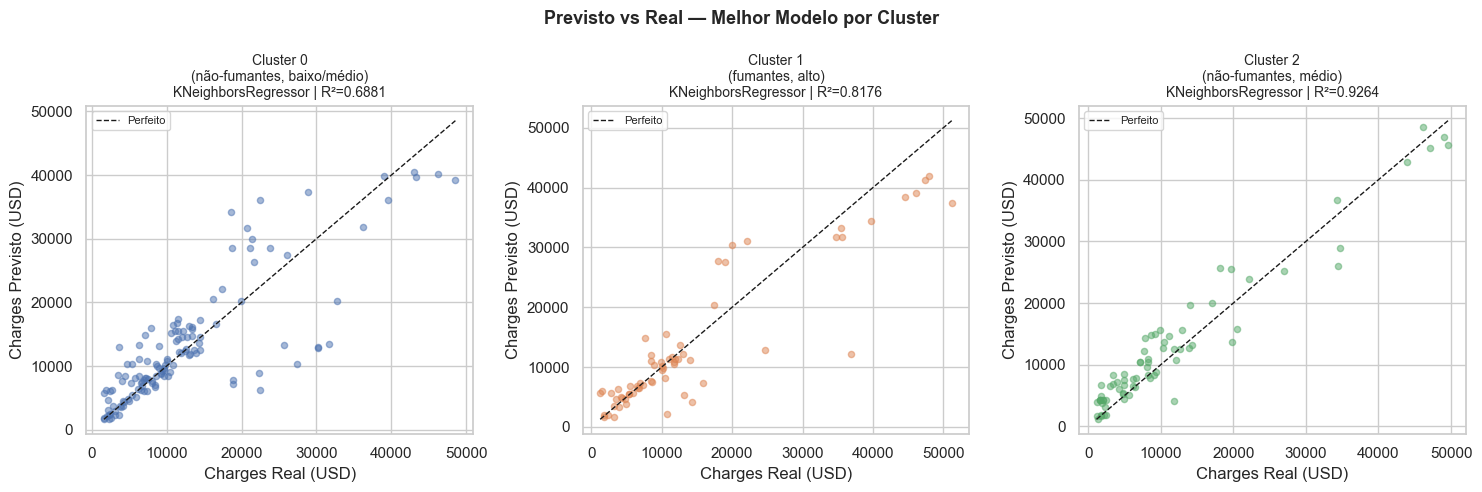

Gráfico salvo: data/previsto_vs_real_clusters.png


In [7]:
# --- Gráfico 2: Previsto vs Real para o melhor modelo de cada cluster ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cluster_labels_plot = [
    'Cluster 0\n(não-fumantes, baixo/médio)',
    'Cluster 1\n(fumantes, alto)',
    'Cluster 2\n(não-fumantes, médio)'
]

for cluster_id in [0, 1, 2]:
    y_real, y_pred = predicoes_por_cluster[cluster_id]
    melhor = modelos_por_cluster[cluster_id]
    r2_val = r2_score(y_real, y_pred)

    ax = axes[cluster_id]
    ax.scatter(y_real, y_pred, alpha=0.5, s=20, color=f'C{cluster_id}')
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='Perfeito')
    ax.set_title(f'{cluster_labels_plot[cluster_id]}\n{melhor.__class__.__name__} | R²={r2_val:.4f}', fontsize=10)
    ax.set_xlabel('Charges Real (USD)')
    ax.set_ylabel('Charges Previsto (USD)')
    ax.legend(fontsize=8)

plt.suptitle('Previsto vs Real — Melhor Modelo por Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/previsto_vs_real_clusters.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo: data/previsto_vs_real_clusters.png')

## Persistência dos Modelos

Os melhores modelos de cada cluster são salvos para utilização na etapa final de predição.

Esses artefatos permitirão realizar previsões sem necessidade de novo treinamento.

In [8]:
# Resultados para Etapa 5 
resultados_df.to_csv('../data/resultados_clusters.csv', index=False)
print(f'Salvo: data/resultados_clusters.csv ({len(resultados_df)} linhas)')

# Melhores modelos para Etapa 6 (pipeline final)
for cluster_id, modelo in modelos_por_cluster.items():
    path = f'../data/modelo_cluster_{cluster_id}.pkl'
    joblib.dump(modelo, path)
    print(f'Salvo: data/modelo_cluster_{cluster_id}.pkl ({modelo.__class__.__name__})')

print('\nArtefatos da Etapa 4 gerados com sucesso!')

Salvo: data/resultados_clusters.csv (9 linhas)
Salvo: data/modelo_cluster_0.pkl (KNeighborsRegressor)
Salvo: data/modelo_cluster_1.pkl (KNeighborsRegressor)
Salvo: data/modelo_cluster_2.pkl (KNeighborsRegressor)

Artefatos da Etapa 4 gerados com sucesso!


## 8. Conclusão

Nesta etapa foram treinados modelos de regressão específicos para cada cluster identificado pelo K-Means.

Os resultados obtidos foram comparados com o modelo global desenvolvido na etapa anterior.

Caso os modelos por cluster apresentem menor erro e maior R², isso indicará que a segmentação dos clientes contribui para melhorar a capacidade de previsão dos custos do seguro médico.

A validação final será realizada na Etapa 5, por meio da comparação direta entre as duas abordagens.